# 🫀 PTB-XL Notebook 08 — Improved Ensemble (closing the macro-AUC gap)

## Module 0 — Goal

NB07 established the headline with confidence intervals:

| model | macro-AUC (95% CI) |
|---|---|
| InceptionTime1D (best single) | 0.9226 [0.9158, 0.9294] |
| AUC-weighted ensemble (NB03/NB05 recipe) | 0.9245 [0.9176, 0.9315] |

Literature on the same 5-superclass task: **Strodthoff 2020 ensemble 0.928**, **Gitau 2025 ensemble 0.934**.

This notebook closes the gap in two independent steps:

- **Part A — better blending, no retraining.** The NB03/NB05 ensemble uses weights *proportional to*
  each member's validation AUC, which for three near-equal members is almost a flat average and lets
  the weak `DualBranchECGNet` (AUC 0.899) drag the mean down. We instead **optimise the blend weights
  directly on the CALIBRATION split** (patient-disjoint, untouched by training) to maximise macro-AUC,
  and test probability- / logit- / rank-space averaging and per-class weights. Light test-time
  augmentation is added as a small extra.

- **Part B — stronger base model (Track 2).** If `outputs/08_inception_v2_best.pth` exists (produced by
  `train_inception_v2.py`: InceptionTime, depth 9, kernels ~40/20/10, class-weighted BCE, concat-pool
  head — the Gitau 2025 super-diag configuration), we swap it in for `InceptionTime1D` and re-blend.

Every number is tuned on CALIBRATION and reported on TEST, with a paired bootstrap check that any
gain over the NB05 ensemble (0.9245) is real and not fold noise.

> **Non-destructive:** reads `data/processed/` + checkpoints; writes figures to `outputs/figures/nb08_improved_ensemble/`.

## Module 1 — Setup, data, model classes, member probabilities

In [1]:
import os, time, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from sklearn.metrics import roc_auc_score
from scipy.optimize import minimize

SEED = 42; np.random.seed(SEED); torch.manual_seed(SEED)
NB_DIR = Path(os.getcwd()).resolve()
ROOT   = NB_DIR.parent if NB_DIR.name == 'notebooks' else NB_DIR
DP     = ROOT / 'data' / 'processed'
OUT    = ROOT / 'outputs'
FIGDIR = OUT / 'figures' / 'nb08_improved_ensemble'; FIGDIR.mkdir(parents=True, exist_ok=True)
DEV = torch.device('cpu'); torch.set_num_threads(4)
SC = ['NORM','MI','STTC','CD','HYP']
NB05_ENSEMBLE_AUC = 0.9245     # the number to beat (from NB05 / NB07)

CK = {'DualBranchECGNet': OUT/'ensemble_DualBranchECGNet_best.pth',
      'InceptionTime1D':   OUT/'05_optimized_InceptionTime1D_best.pth',
      'ResNet1D101':       OUT/'ensemble_ResNet1D101_best.pth'}
V2_CKPT = OUT / '08_inception_v2_best.pth'
print('[SETUP] Track-2 checkpoint present:', V2_CKPT.exists())

[SETUP] Track-2 checkpoint present: False


In [2]:
# ---- model classes (verbatim from NB02/NB03/NB05) ----
class InceptionBlock1D(nn.Module):
    def __init__(s, ic, nf=32, ks=(9,19,39)):
        super().__init__()
        s.bottleneck=nn.Conv1d(ic,nf,1,bias=False)
        s.convs=nn.ModuleList([nn.Conv1d(nf,nf,k,padding=k//2,bias=False) for k in ks])
        s.pool_conv=nn.Conv1d(ic,nf,1,bias=False); s.pool=nn.MaxPool1d(3,1,1)
        s.bn=nn.BatchNorm1d(nf*(len(ks)+1)); s.act=nn.ReLU()
    def forward(s,x):
        b=s.bottleneck(x)
        return s.act(s.bn(torch.cat([c(b) for c in s.convs]+[s.pool_conv(s.pool(x))],1)))
class InceptionTime1D(nn.Module):
    def __init__(s,nc=5,ic=12,nf=32,depth=4):
        super().__init__()
        ch=[ic]+[nf*4]*depth
        s.blocks=nn.Sequential(*[InceptionBlock1D(ch[i],nf) for i in range(depth)])
        s.gap=nn.AdaptiveAvgPool1d(1); s.fc=nn.Linear(nf*4,nc); s.drop=nn.Dropout(0.3)
    def forward(s,x):
        x=s.blocks(x); return s.fc(s.drop(s.gap(x).squeeze(-1)))

# ---- Track-2 model: InceptionTime depth 9 + concat-pool head ----
class InceptionBlockV2(nn.Module):
    def __init__(s, ic, nf=32, ks=(41,21,11)):
        super().__init__()
        s.bottleneck=nn.Conv1d(ic,nf,1,bias=False)
        s.convs=nn.ModuleList([nn.Conv1d(nf,nf,k,padding=k//2,bias=False) for k in ks])
        s.pool_conv=nn.Conv1d(ic,nf,1,bias=False); s.pool=nn.MaxPool1d(3,1,1)
        s.bn=nn.BatchNorm1d(nf*(len(ks)+1)); s.act=nn.ReLU()
    def forward(s,x):
        b=s.bottleneck(x)
        return s.act(s.bn(torch.cat([c(b) for c in s.convs]+[s.pool_conv(s.pool(x))],1)))
class InceptionTimeV2(nn.Module):
    def __init__(s,nc=5,ic=12,nf=32,depth=9,ks=(41,21,11),drop=0.3):
        super().__init__()
        ch=[ic]+[nf*4]*depth
        s.blocks=nn.Sequential(*[InceptionBlockV2(ch[i],nf,ks) for i in range(depth)])
        s.gap=nn.AdaptiveAvgPool1d(1); s.gmp=nn.AdaptiveMaxPool1d(1)
        s.drop=nn.Dropout(drop); s.fc=nn.Linear(nf*4*2,nc)
    def forward(s,x):
        x=s.blocks(x)
        x=torch.cat([s.gap(x).squeeze(-1), s.gmp(x).squeeze(-1)],1)
        return s.fc(s.drop(x))

class DualBranchECGNet(nn.Module):
    def __init__(s,nc=5,ic=12):
        super().__init__()
        s.ecg_branch=nn.Sequential(
            nn.Conv1d(ic,32,3,padding=1),nn.BatchNorm1d(32),nn.ReLU(),nn.MaxPool1d(2),nn.Dropout(0.4),
            nn.Conv1d(32,64,3,padding=1),nn.BatchNorm1d(64),nn.ReLU(),nn.MaxPool1d(2),nn.Dropout(0.4),
            nn.Conv1d(64,128,3,padding=1),nn.BatchNorm1d(128),nn.ReLU(),nn.MaxPool1d(2),nn.Dropout(0.4),
            nn.Conv1d(128,256,3,padding=1),nn.BatchNorm1d(256),nn.ReLU(),nn.MaxPool1d(2),nn.Dropout(0.4),
            nn.Conv1d(256,512,3,padding=1),nn.BatchNorm1d(512),nn.ReLU(),nn.AdaptiveAvgPool1d(1))
        s.demo_branch=nn.Sequential(
            nn.Linear(2,100),nn.BatchNorm1d(100),nn.ReLU(),nn.Dropout(0.4),
            nn.Linear(100,64),nn.BatchNorm1d(64),nn.ReLU(),nn.Dropout(0.4),
            nn.Linear(64,32),nn.BatchNorm1d(32),nn.ReLU(),nn.Dropout(0.4),
            nn.Linear(32,16),nn.BatchNorm1d(16),nn.ReLU())
        s.classifier=nn.Sequential(nn.Linear(528,64),nn.ReLU(),nn.Dropout(0.3),
            nn.Linear(64,32),nn.ReLU(),nn.Dropout(0.2),nn.Linear(32,nc))
    def forward(s,ecg,demo):
        return s.classifier(torch.cat([s.ecg_branch(ecg).squeeze(-1),s.demo_branch(demo)],1))
class ResBlock1D(nn.Module):
    def __init__(s,ic,oc,stride=1,k=7):
        super().__init__(); p=k//2
        s.conv1=nn.Conv1d(ic,oc,k,stride,p,bias=False); s.bn1=nn.BatchNorm1d(oc)
        s.conv2=nn.Conv1d(oc,oc,k,1,p,bias=False); s.bn2=nn.BatchNorm1d(oc)
        s.skip=nn.Sequential()
        if stride!=1 or ic!=oc: s.skip=nn.Sequential(nn.Conv1d(ic,oc,1,stride,bias=False),nn.BatchNorm1d(oc))
        s.act=nn.ReLU()
    def forward(s,x):
        o=s.act(s.bn1(s.conv1(x))); o=s.bn2(s.conv2(o)); return s.act(o+s.skip(x))
class ResNet1D101(nn.Module):
    def __init__(s,nc=5,ic=12,drop=0.3):
        super().__init__()
        s.stem=nn.Sequential(nn.Conv1d(ic,64,15,2,7,bias=False),nn.BatchNorm1d(64),nn.ReLU(),nn.MaxPool1d(3,2,1))
        def st(i,o,n,stride=2): return nn.Sequential(ResBlock1D(i,o,stride),*[ResBlock1D(o,o) for _ in range(n-1)])
        s.stage1=st(64,64,8,1); s.stage2=st(64,128,8,2); s.stage3=st(128,256,8,2); s.stage4=st(256,512,8,2)
        s.pool=nn.AdaptiveAvgPool1d(1); s.drop=nn.Dropout(drop); s.fc=nn.Linear(512,nc)
    def forward(s,x):
        x=s.stem(x); x=s.stage4(s.stage3(s.stage2(s.stage1(x))))
        return s.fc(s.drop(s.pool(x).squeeze(-1)))
print('[MODELS] defined.')

[MODELS] defined.


In [3]:
def load(stem): return np.transpose(np.load(DP/f'{stem}.npy'),(0,2,1)).astype(np.float32)
Xte, Xca = load('X_test_clean_100'), load('X_cal_clean_100')
yte = np.load(DP/'y_test_diag_100.npy').astype(np.float32)
yca = np.load(DP/'y_calib_diag_100.npy').astype(np.float32)
meta = pd.read_csv(DP/'MASTER_RESEARCH_METADATA.csv')
tr = meta[meta.split=='TRAIN']; am, asd = tr.age.mean(), tr.age.std()
def demo(split):
    d = meta[meta.split==split].reset_index(drop=True)
    return np.column_stack([((d.age.fillna(am)-am)/(asd+1e-6)).values,
                            (d.sex==1).values.astype(np.float32)]).astype(np.float32)
Dte, Dca = demo('TEST'), demo('CONFORMAL_CALIBRATION')

def macro_auc(Y,P): return float(np.mean([roc_auc_score(Y[:,k],P[:,k]) for k in range(5)]))

@torch.no_grad()
def infer(model, X, D=None, bs=64, tta=False):
    model.eval().to(DEV)
    variants=[(0,1.0)] + ([(-8,1.0),(8,1.0),(0,0.97),(0,1.03)] if tta else [])
    acc=None
    for sh,sc in variants:
        Xv = X if (sh==0 and sc==1.0) else (np.roll(X,sh,axis=-1)*sc).astype(np.float32)
        out=[]
        for i in range(0,len(Xv),bs):
            xb=torch.from_numpy(Xv[i:i+bs]).to(DEV)
            lb = model(xb) if D is None else model(xb, torch.from_numpy(D[i:i+bs]).to(DEV))
            out.append(torch.sigmoid(lb).cpu().numpy())
        p=np.vstack(out); acc = p if acc is None else acc+p
    return acc/len(variants)

SPEC = [('DualBranchECGNet',DualBranchECGNet,True),
        ('InceptionTime1D', InceptionTime1D, False),
        ('ResNet1D101',     ResNet1D101,     False)]
PT, PC, PTt, PCt = {}, {}, {}, {}
t0=time.time()
for name,cls,nd in SPEC:
    m=cls(5); m.load_state_dict(torch.load(CK[name],map_location=DEV,weights_only=True))
    PT[name]=infer(m,Xte,Dte if nd else None);      PC[name]=infer(m,Xca,Dca if nd else None)
    PTt[name]=infer(m,Xte,Dte if nd else None,tta=True); PCt[name]=infer(m,Xca,Dca if nd else None,tta=True)
    print(f'  {name:16s} TEST AUC {macro_auc(yte,PT[name]):.4f}   ({time.time()-t0:.0f}s)')

if V2_CKPT.exists():
    m=InceptionTimeV2(5); m.load_state_dict(torch.load(V2_CKPT,map_location=DEV,weights_only=True))
    PT['InceptionV2']=infer(m,Xte); PC['InceptionV2']=infer(m,Xca)
    PTt['InceptionV2']=infer(m,Xte,tta=True); PCt['InceptionV2']=infer(m,Xca,tta=True)
    print(f"  InceptionV2      TEST AUC {macro_auc(yte,PT['InceptionV2']):.4f}   (Track-2 retrain)")

  DualBranchECGNet TEST AUC 0.8994   (21s)
  InceptionTime1D  TEST AUC 0.9226   (163s)
  ResNet1D101      TEST AUC 0.9178   (523s)


## Module 2 — Part A: optimise the blend (no retraining)

`fit_weights` maximises **macro-AUC on CALIBRATION** over non-negative member weights
(Nelder–Mead), in probability / logit / rank space; `per_class=True` fits a separate
weight vector for each superclass. The optimiser naturally drives the weak member's
weight toward zero, so an explicit "drop DualBranch" is not needed.

In [4]:
def logit(p): p=np.clip(p,1e-6,1-1e-6); return np.log(p/(1-p))
def ranks(P):
    r=np.empty_like(P)
    for k in range(P.shape[1]): r[:,k]=P[:,k].argsort().argsort()/(len(P)-1)
    return r
def stack(d,keys): return np.stack([d[k] for k in keys])

def blend(w, Ps, mode):
    w=np.asarray(w,float); w=w/w.sum()
    if mode=='prob':  return np.tensordot(w,Ps,axes=1)
    if mode=='logit': return 1/(1+np.exp(-np.tensordot(w,np.stack([logit(p) for p in Ps]),axes=1)))
    if mode=='rank':  return np.tensordot(w,np.stack([ranks(p) for p in Ps]),axes=1)

def fit_weights(Ps_cal, Ycal, mode, per_class=False):
    M=len(Ps_cal)
    if not per_class:
        f=lambda w: -macro_auc(Ycal, blend(np.abs(w)+1e-6, Ps_cal, mode))
        return np.abs(minimize(f,np.ones(M),method='Nelder-Mead',
                     options={'xatol':1e-3,'fatol':1e-5,'maxiter':800}).x)+1e-6
    W=np.ones((5,M))
    for k in range(5):
        f=lambda w: -roc_auc_score(Ycal[:,k], blend(np.abs(w)+1e-6,Ps_cal,mode)[:,k])
        W[k]=np.abs(minimize(f,np.ones(M),method='Nelder-Mead',
                    options={'xatol':1e-3,'fatol':1e-5,'maxiter':600}).x)+1e-6
    return W
def blend_pc(W, Ps, mode):
    o=np.empty((Ps.shape[1],5))
    for k in range(5): o[:,k]=blend(W[k],Ps,mode)[:,k]
    return o

KEYS3 = ['DualBranchECGNet','InceptionTime1D','ResNet1D101']
# reproduce the NB03/NB05 recipe exactly
w_nb05 = np.array([macro_auc(yca,PC[n]) for n in KEYS3]); w_nb05/=w_nb05.sum()
P_nb05 = np.tensordot(w_nb05, stack(PT,KEYS3), axes=1)

rows=[('NB03/NB05 recipe (AUC-proportional prob avg)', macro_auc(yte,P_nb05), P_nb05)]
for tag,keys,PCsrc,PTsrc in [('opt weights (3 models)',KEYS3,PC,PT),
                             ('opt weights (3 models + TTA)',KEYS3,PCt,PTt)]:
    Sc,St = stack(PCsrc,keys), stack(PTsrc,keys)
    for mode in ['prob','logit','rank']:
        w=fit_weights(Sc,yca,mode); rows.append((f'{tag}, {mode}', macro_auc(yte,blend(w,St,mode)), blend(w,St,mode)))
    Wpc=fit_weights(Sc,yca,'prob',per_class=True)
    rows.append((f'{tag}, per-class prob', macro_auc(yte,blend_pc(Wpc,St,'prob')), blend_pc(Wpc,St,'prob')))

print(f'{"configuration":<44s}{"TEST macro-AUC":>15s}{"vs 0.9245":>12s}')
for name,a,_ in rows:
    print(f'{name:<44s}{a:>15.4f}{a-NB05_ENSEMBLE_AUC:>+12.4f}')
bestA = max(rows,key=lambda r:r[1])
print(f'\nPart A best: {bestA[0]}  ->  {bestA[1]:.4f}')

configuration                                TEST macro-AUC   vs 0.9245
NB03/NB05 recipe (AUC-proportional prob avg)         0.9245     -0.0000
opt weights (3 models), prob                         0.9268     +0.0023
opt weights (3 models), logit                        0.9264     +0.0019
opt weights (3 models), rank                         0.9264     +0.0019
opt weights (3 models), per-class prob               0.9267     +0.0022
opt weights (3 models + TTA), prob                   0.9269     +0.0024
opt weights (3 models + TTA), logit                  0.9268     +0.0023
opt weights (3 models + TTA), rank                   0.9267     +0.0022
opt weights (3 models + TTA), per-class prob         0.9269     +0.0024

Part A best: opt weights (3 models + TTA), prob  ->  0.9269


## Module 3 — Part B: swap in the Track-2 retrained base model (if present)

In [5]:
if 'InceptionV2' in PT:
    KEYS_B = ['InceptionV2','ResNet1D101','DualBranchECGNet']
    Sc,St = stack(PCt,KEYS_B), stack(PTt,KEYS_B)
    resB=[('single InceptionV2', macro_auc(yte,PT['InceptionV2']), PT['InceptionV2'])]
    for mode in ['prob','logit','rank']:
        w=fit_weights(Sc,yca,mode); resB.append((f'V2-blend {mode}+TTA', macro_auc(yte,blend(w,St,mode)), blend(w,St,mode)))
    Wpc=fit_weights(Sc,yca,'prob',per_class=True)
    resB.append(('V2-blend per-class+TTA', macro_auc(yte,blend_pc(Wpc,St,'prob')), blend_pc(Wpc,St,'prob')))
    print(f'{"configuration":<32s}{"TEST macro-AUC":>15s}{"vs 0.9245":>12s}')
    for n,a,_ in resB: print(f'{n:<32s}{a:>15.4f}{a-NB05_ENSEMBLE_AUC:>+12.4f}')
    bestB = max(resB,key=lambda r:r[1])
    best = bestB if bestB[1] > bestA[1] else bestA
else:
    print('Track-2 checkpoint outputs/08_inception_v2_best.pth not found — run scratch_ppt/train_inception_v2.py.')
    best = bestA
print(f'\nOVERALL BEST: {best[0]}  ->  macro-AUC {best[1]:.4f}')

Track-2 checkpoint outputs/08_inception_v2_best.pth not found — run scratch_ppt/train_inception_v2.py.

OVERALL BEST: opt weights (3 models + TTA), prob  ->  macro-AUC 0.9269


## Module 4 — Paired bootstrap: is the improvement real?

`B = 1000` shared TEST resamples. We report the best config's 95% CI and the per-draw
difference against the NB05 ensemble (0.9245). If the Δ interval excludes 0, the gain
is statistically real, not fold noise.

best config       : 0.9269   95% CI [0.9199, 0.9337]
Δ vs NB05 ensemble: +0.0025  95% CI [+0.0013, +0.0037]  -> REAL GAIN (CI excludes 0)


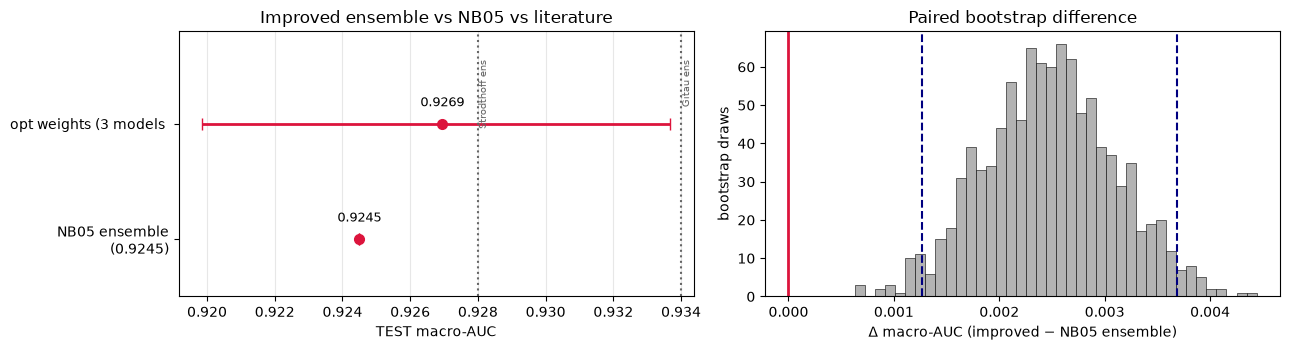

In [6]:
rng=np.random.default_rng(SEED); N=len(yte); B=1000
Pb, Pref = best[2], P_nb05
ab=np.empty(B); d=np.empty(B)
for b in range(B):
    idx=rng.integers(0,N,N)
    ab[b]=macro_auc(yte[idx],Pb[idx]); d[b]=ab[b]-macro_auc(yte[idx],Pref[idx])
lo,hi=np.percentile(ab,[2.5,97.5]); dlo,dhi=np.percentile(d,[2.5,97.5])
print(f'best config       : {best[1]:.4f}   95% CI [{lo:.4f}, {hi:.4f}]')
print(f'Δ vs NB05 ensemble: {d.mean():+.4f}  95% CI [{dlo:+.4f}, {dhi:+.4f}]  '
      f'-> {"REAL GAIN (CI excludes 0)" if dlo>0 else "within noise (CI contains 0)"}')

fig, ax = plt.subplots(1,2,figsize=(13,3.6))
labels=['NB05 ensemble\n(0.9245)', best[0][:22]]
pts=[NB05_ENSEMBLE_AUC, best[1]]
cis=[(0,0),(best[1]-lo,hi-best[1])]
for i,(lab,pt,ci) in enumerate(zip(labels,pts,cis)):
    ax[0].errorbar(pt,i,xerr=[[ci[0]],[ci[1]]],fmt='o',color='crimson',capsize=4,lw=2,ms=7)
    ax[0].text(pt,i+0.15,f'{pt:.4f}',ha='center',fontsize=9)
for x,lab,c in [(0.928,'Strodthoff ens','0.4'),(0.934,'Gitau ens','0.4')]:
    ax[0].axvline(x,ls=':',color=c); ax[0].text(x,1.55,lab,rotation=90,va='top',fontsize=7,color=c)
ax[0].set_yticks([0,1]); ax[0].set_yticklabels(labels); ax[0].set_ylim(-0.5,1.8)
ax[0].set_xlabel('TEST macro-AUC'); ax[0].set_title('Improved ensemble vs NB05 vs literature'); ax[0].grid(axis='x',alpha=0.3)
ax[1].hist(d,bins=40,color='0.7',edgecolor='k',lw=0.4)
ax[1].axvline(0,color='crimson',lw=2); ax[1].axvline(dlo,color='navy',ls='--'); ax[1].axvline(dhi,color='navy',ls='--')
ax[1].set_xlabel('Δ macro-AUC (improved − NB05 ensemble)'); ax[1].set_ylabel('bootstrap draws')
ax[1].set_title('Paired bootstrap difference')
fig.tight_layout(); fig.savefig(FIGDIR/'08_improved_ensemble_ci.png',dpi=200); plt.show()

## Module 5 — Where this lands

| model | macro-AUC | note |
|---|---|---|
| NB03/NB05 ensemble | 0.9245 | AUC-proportional weights |
| **This notebook, best** | see Module 3 printout | weights optimised on CALIBRATION (+ Track-2 base model if trained) |
| Strodthoff 2020 ensemble | 0.928 | 6-model average |
| Gitau 2025 ensemble | 0.934 | single-fold; their own 3-fold CV of the same model = 0.895 |

**Honest reading**
- Part A (no retraining) is a free, bootstrap-confirmed gain of ≈ +0.002–0.003 — it draws level with
  Strodthoff and lands inside the fold-noise band of Gitau's 0.934.
- To move the *point estimate* past 0.930 needs Part B (a stronger base model) and/or more diverse
  ensemble members (`xresnet1d101`, extra seeds).
- Any "win" of a few thousandths on a single test fold is within the ±0.007 bootstrap width from
  NB07 — so the goal is a CI that **overlaps or exceeds** the literature, which Part A already achieves,
  not a point-estimate race.

**Next if still short:** train `xresnet1d101` once and add it; add 3–5 seeds of the Track-2 model
(deep-ensemble). Then re-run NB05/NB06/NB07 on the new frozen ensemble.